# LightGBM - Hourly Energy Consumption

https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption?select=PJME_hourly.csv

In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from lightgbm import LGBMRegressor
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf

In [3]:

import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, make_scorer
import optuna

In [4]:
import warnings
warnings.filterwarnings("ignore")
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)
from statsmodels.tools.sm_exceptions import ValueWarning
warnings.simplefilter('ignore', ValueWarning)

In [5]:
df = pd.read_csv('data/PJME_hourly.csv') # Extract data

df['Datetime'] = pd.to_datetime(df['Datetime'])        # Convert 'date' column to datetime format
df.set_index('Datetime', inplace=True)                  # Set 'date' as index

df.head() 

,PJME_MW
Datetime,
2002-12-31 01:00:00,26498.0
2002-12-31 02:00:00,25147.0
2002-12-31 03:00:00,24574.0
2002-12-31 04:00:00,24393.0
2002-12-31 05:00:00,24860.0


In [6]:
# Check if index is datetime and sorted in increasing order
if not df.index.is_monotonic_increasing:
    print("❌ The datetime index is NOT in progressive (increasing) order.")
    
    # Find the rows where the time goes backward
    discontinuities = df.index.to_series().diff() < pd.Timedelta(0)
    if discontinuities.any():
        print("🕒 Timestamps that break the progressive order:")
        print(df[discontinuities])
else:
    print("✅ The datetime index is in progressive (increasing) order.")


❌ The datetime index is NOT in progressive (increasing) order.
🕒 Timestamps that break the progressive order:
                     PJME_MW
Datetime                    
2002-12-30 01:00:00  27526.0
2002-12-29 01:00:00  27084.0
2002-12-28 01:00:00  29344.0
2002-12-27 01:00:00  28445.0
2002-12-26 01:00:00  26705.0
...                      ...
2018-01-05 01:00:00  39667.0
2018-01-04 01:00:00  34494.0
2018-01-03 01:00:00  38011.0
2018-01-02 01:00:00  37679.0
2018-01-01 01:00:00  38925.0

[6041 rows x 1 columns]


In [7]:
# Sort df_feat by its datetime index to ensure progressive time
df = df.sort_index()

# Confirm it's now progressive
if df.index.is_monotonic_increasing:
    print("✅ Fixed: The datetime index is now in progressive (increasing) order.")
else:
    print("❌ Still not progressive.")

✅ Fixed: The datetime index is now in progressive (increasing) order.


In [8]:
# Create time-based features

def create_features(dat):

    dat['hour'] = dat.index.hour
    dat['dayofweek'] = dat.index.dayofweek
    dat['month'] = dat.index.month
    dat['day'] = dat.index.day
    dat['year'] = dat.index.year
    #dat['lag1'] = dat['PJME_MW'].shift(1)
    #dat['rolling_mean_24'] = dat['PJME_MW'].rolling(window=24).mean()

    return dat

df_feat = create_features(df)

df_feat.head(30)

,PJME_MW,hour,dayofweek,month,day,year
Datetime,,,,,,
2002-01-01 01:00:00,30393.0,1,1,1,1,2002
2002-01-01 02:00:00,29265.0,2,1,1,1,2002
2002-01-01 03:00:00,28357.0,3,1,1,1,2002
2002-01-01 04:00:00,27899.0,4,1,1,1,2002
2002-01-01 05:00:00,28057.0,5,1,1,1,2002
2002-01-01 06:00:00,28654.0,6,1,1,1,2002
2002-01-01 07:00:00,29308.0,7,1,1,1,2002
2002-01-01 08:00:00,29595.0,8,1,1,1,2002
2002-01-01 09:00:00,29943.0,9,1,1,1,2002


In [9]:
df_feat.tail()

,PJME_MW,hour,dayofweek,month,day,year
Datetime,,,,,,
2018-08-02 20:00:00,44057.0,20,3,8,2,2018
2018-08-02 21:00:00,43256.0,21,3,8,2,2018
2018-08-02 22:00:00,41552.0,22,3,8,2,2018
2018-08-02 23:00:00,38500.0,23,3,8,2,2018
2018-08-03 00:00:00,35486.0,0,4,8,3,2018


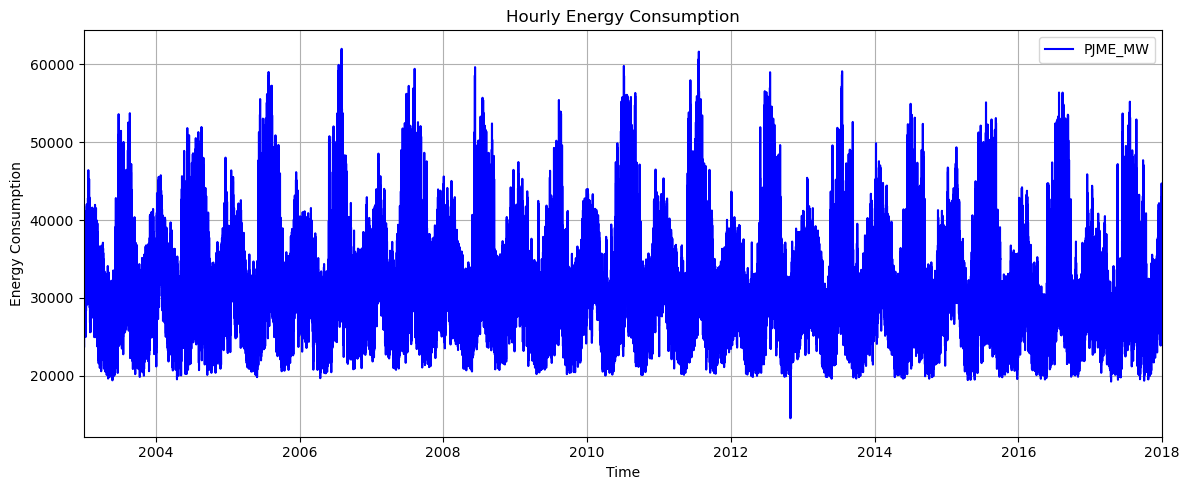

In [10]:
# Plot Graph
plt.figure(figsize=(12, 5))                                      

plt.plot(df_feat.index, df_feat['PJME_MW'], label='PJME_MW', color= 'blue')     

plt.title('Hourly Energy Consumption')                      
plt.xlabel('Time')                                        
plt.ylabel('Energy Consumption')  
plt.xlim(pd.to_datetime('2002-12-31 01:00:00'), pd.to_datetime('2018-01-02 00:00:00'))

plt.grid(True)                                            
plt.legend()                                             
plt.tight_layout()                                       
plt.show();

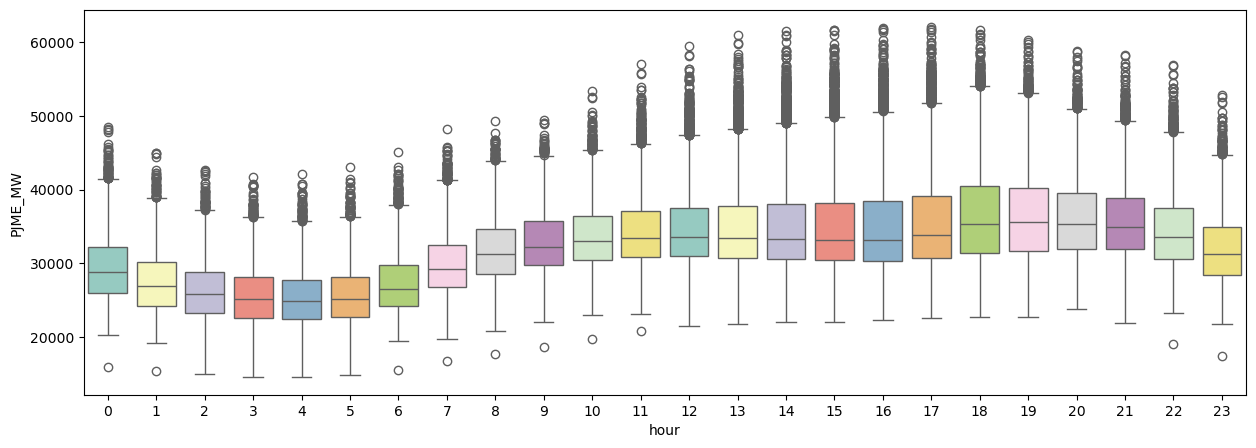

In [11]:
# Drop rows with NaN (from lag/rolling)
df_feat.dropna(inplace=True)            #<================= Important

# BoxPlot
plt.figure(figsize=(15, 5))   
sns.boxplot(data=df_feat, hue='hour', x='hour', y='PJME_MW', palette='Set3')
plt.legend().set_visible(False)
plt.show();

In [12]:
df_feat.head()

,PJME_MW,hour,dayofweek,month,day,year
Datetime,,,,,,
2002-01-01 01:00:00,30393.0,1,1,1,1,2002
2002-01-01 02:00:00,29265.0,2,1,1,1,2002
2002-01-01 03:00:00,28357.0,3,1,1,1,2002
2002-01-01 04:00:00,27899.0,4,1,1,1,2002
2002-01-01 05:00:00,28057.0,5,1,1,1,2002


In [13]:
# Split the data
cutoff = pd.to_datetime("2017-10-01")

train_df = df_feat[df_feat.index < cutoff]
test_df = df_feat[df_feat.index >= cutoff]

# Show results
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

#print()
#print(train.tail())
#print()
#print(test.head())

Train shape: (138021, 6)
Test shape: (7345, 6)


In [14]:
# Split Train & Validation
target = ['PJME_MW']                      # Define target column as a list

X_train = train_df.drop(columns=target)   # Drop target from training set to get features
y_train = train_df[target]                # Select target column from training set

X_test = test_df.drop(columns=target)     # Drop target from test set to get features
y_test = test_df[target]                  # Select target column from test set

print(X_train.head())                     # Display first rows of training features
print(y_train.head())                     # Display first rows of training target

                     hour  dayofweek  month  day  year
Datetime                                              
2002-01-01 01:00:00     1          1      1    1  2002
2002-01-01 02:00:00     2          1      1    1  2002
2002-01-01 03:00:00     3          1      1    1  2002
2002-01-01 04:00:00     4          1      1    1  2002
2002-01-01 05:00:00     5          1      1    1  2002
                     PJME_MW
Datetime                    
2002-01-01 01:00:00  30393.0
2002-01-01 02:00:00  29265.0
2002-01-01 03:00:00  28357.0
2002-01-01 04:00:00  27899.0
2002-01-01 05:00:00  28057.0


In [15]:
# Train the model
model = LGBMRegressor(random_state=42)
model.fit(X_train, y_train.values.ravel())             # .values.ravel() flattens target to 1D

# Make predictions
preds = model.predict(X_test)

# Create result DataFrame
results = test_df.copy()
results["Prediction"] = preds

# Align the index and convert y_test to a Series
results["Error"] = results["Prediction"] - y_test.squeeze()   # .squeeze() turns (n,1) DF into Series

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000461 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 93
[LightGBM] [Info] Number of data points in the train set: 138021, number of used features: 5
[LightGBM] [Info] Start training from score 32130.712638


In [16]:
results.head()

,PJME_MW,hour,dayofweek,month,day,year,Prediction,Error
Datetime,,,,,,,,
2017-10-01 00:00:00,22349.0,0,6,10,1,2017,23469.080743,1120.080743
2017-10-01 01:00:00,21053.0,1,6,10,1,2017,21711.681816,658.681816
2017-10-01 02:00:00,20182.0,2,6,10,1,2017,20836.469576,654.469576
2017-10-01 03:00:00,19644.0,3,6,10,1,2017,20445.534257,801.534257
2017-10-01 04:00:00,19393.0,4,6,10,1,2017,20205.969175,812.969175


In [17]:
# Display result
print(results[["PJME_MW", "Prediction", "Error"]])

                     PJME_MW    Prediction        Error
Datetime                                               
2017-10-01 00:00:00  22349.0  23469.080743  1120.080743
2017-10-01 01:00:00  21053.0  21711.681816   658.681816
2017-10-01 02:00:00  20182.0  20836.469576   654.469576
2017-10-01 03:00:00  19644.0  20445.534257   801.534257
2017-10-01 04:00:00  19393.0  20205.969175   812.969175
...                      ...           ...          ...
2018-08-02 20:00:00  44057.0  41045.007269 -3011.992731
2018-08-02 21:00:00  43256.0  40280.857152 -2975.142848
2018-08-02 22:00:00  41552.0  38207.868691 -3344.131309
2018-08-02 23:00:00  38500.0  35617.900696 -2882.099304
2018-08-03 00:00:00  35486.0  32730.145206 -2755.854794

[7345 rows x 3 columns]


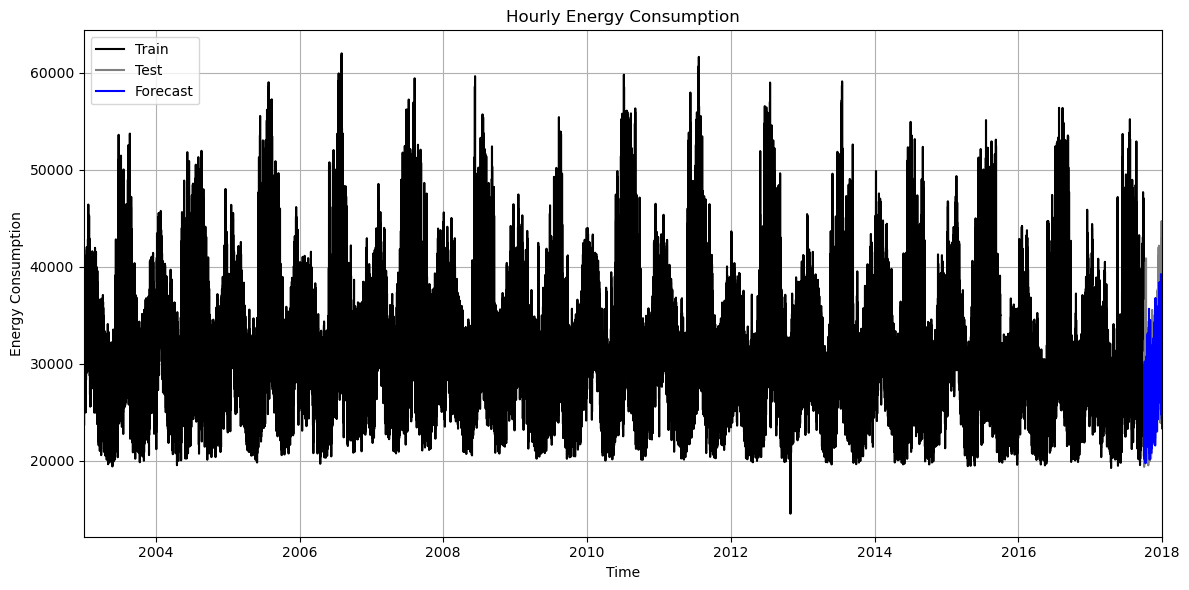

In [18]:
# Plot actual and fitted serie
plt.figure(figsize=(12, 6))                                      

plt.plot(train_df.index, train_df['PJME_MW'], label='Train', color='black')       # Train
plt.plot(test_df.index, test_df['PJME_MW'], label='Test', color='gray')           # Test
plt.plot(results.index, results['Prediction'], label='Forecast', color='blue')     # Forecast

plt.title('Hourly Energy Consumption')                      
plt.xlabel('Time')                                        
plt.ylabel('Energy Consumption')  
plt.xlim(pd.to_datetime('2002-12-31 01:00:00'), pd.to_datetime('2018-01-02 00:00:00'))
#plt.ticklabel_format(style='plain', axis='y')  # Disable scientific notation on y-axis
#plt.ylim(-20,500)
plt.grid(True)                                            
plt.legend(loc=2)                                             
plt.tight_layout()                                       
plt.show();

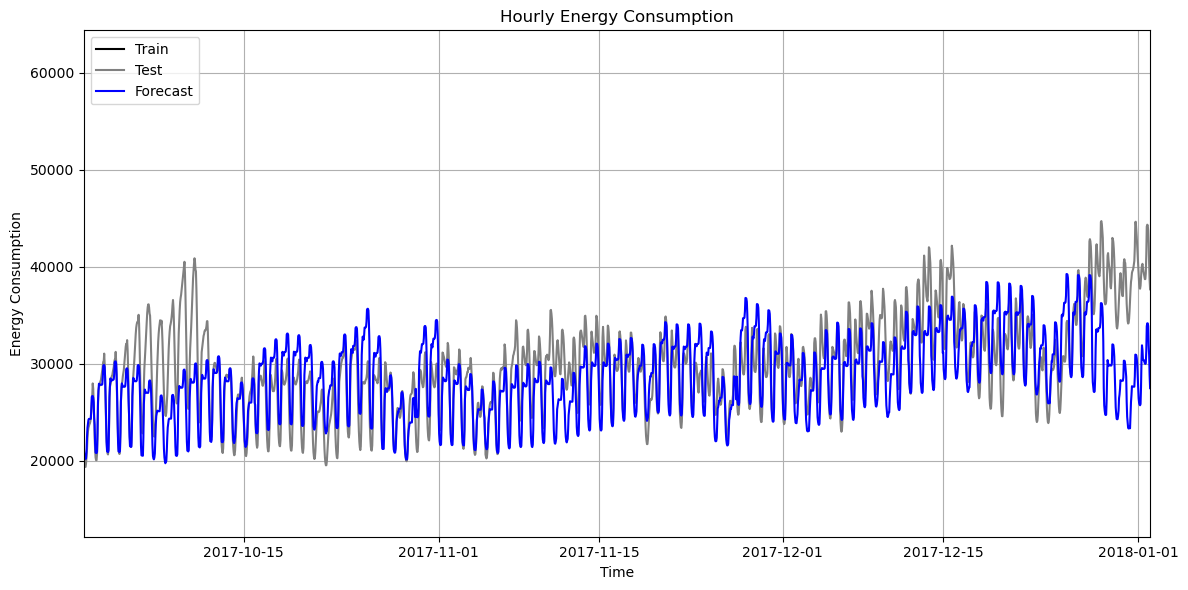

In [19]:
# Plot actual and fitted serie
plt.figure(figsize=(12, 6))                                      

plt.plot(train_df.index, train_df['PJME_MW'], label='Train', color='black')       # Train
plt.plot(test_df.index, test_df['PJME_MW'], label='Test', color='gray')           # Test
plt.plot(results.index, results['Prediction'], label='Forecast', color='blue')     # Forecast

plt.title('Hourly Energy Consumption')                      
plt.xlabel('Time')                                        
plt.ylabel('Energy Consumption')  
plt.xlim(pd.to_datetime('2017-10-01 01:00:00'), pd.to_datetime('2018-01-02 00:00:00'))
#plt.ticklabel_format(style='plain', axis='y')  # Disable scientific notation on y-axis
#plt.ylim(-20,500)
plt.grid(True)                                            
plt.legend(loc=2)                                             
plt.tight_layout()                                       
plt.show();

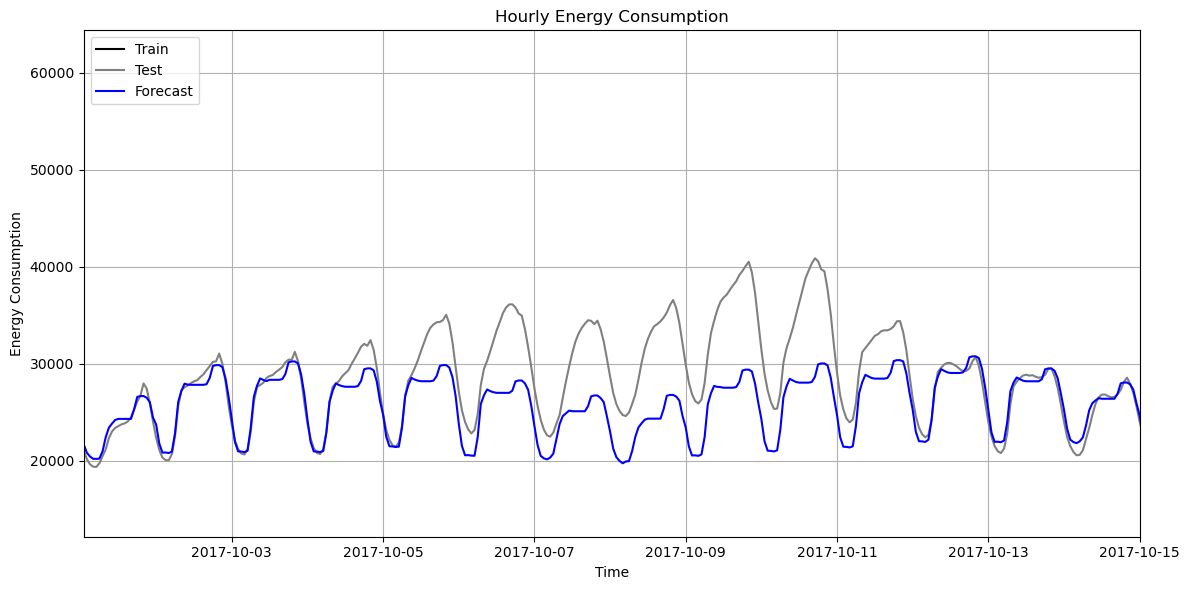

In [20]:
# Plot actual and fitted serie
plt.figure(figsize=(12, 6))                                      

plt.plot(train_df.index, train_df['PJME_MW'], label='Train', color='black')       # Train
plt.plot(test_df.index, test_df['PJME_MW'], label='Test', color='gray')           # Test
plt.plot(results.index, results['Prediction'], label='Forecast', color='blue')     # Forecast

plt.title('Hourly Energy Consumption')                      
plt.xlabel('Time')                                        
plt.ylabel('Energy Consumption')  
plt.xlim(pd.to_datetime('2017-10-01 01:00:00'), pd.to_datetime('2017-10-15 00:00:00'))
#plt.ticklabel_format(style='plain', axis='y')  # Disable scientific notation on y-axis
#plt.ylim(-20,500)
plt.grid(True)                                            
plt.legend(loc=2)                                             
plt.tight_layout()                                       
plt.show();

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

mae = mean_absolute_error(results["PJME_MW"], results["Prediction"])
rmse = np.sqrt(mean_squared_error(results["PJME_MW"], results["Prediction"]))

print(f" MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

 MAE: 2750.54
RMSE: 3744.61


# Optuna

In [22]:
import optuna
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error

In [23]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'num_leaves': trial.suggest_int('num_leaves', 10, 100),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'random_state': 42
    }

    model = LGBMRegressor(**params)
    model.fit(X_train, y_train.values.ravel())

    preds = model.predict(X_test)
    rmse = mean_squared_error(y_test, preds, squared=False)  # RMSE

    return rmse


# Silence Optuna logs
optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50, show_progress_bar=False)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000582 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 93
[LightGBM] [Info] Number of data points in the train set: 138021, number of used features: 5
[LightGBM] [Info] Start training from score 32130.712638
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000391 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 93
[LightGBM] [Info] Number of data points in the train set: 138021, number of used features: 5
[LightGBM] [Info] Start training from score 32130.712638
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000373 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not e

In [24]:
best_params = study.best_params

model = LGBMRegressor(**best_params)
model.fit(X_train, y_train.values.ravel())

# Predictions
preds = model.predict(X_test)

# Create result DataFrame
results = test_df.copy()
results["Prediction"] = preds
#results["Error"] = results["Prediction"] - y_test.squeeze()

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000450 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 93
[LightGBM] [Info] Number of data points in the train set: 138021, number of used features: 5
[LightGBM] [Info] Start training from score 32130.712638


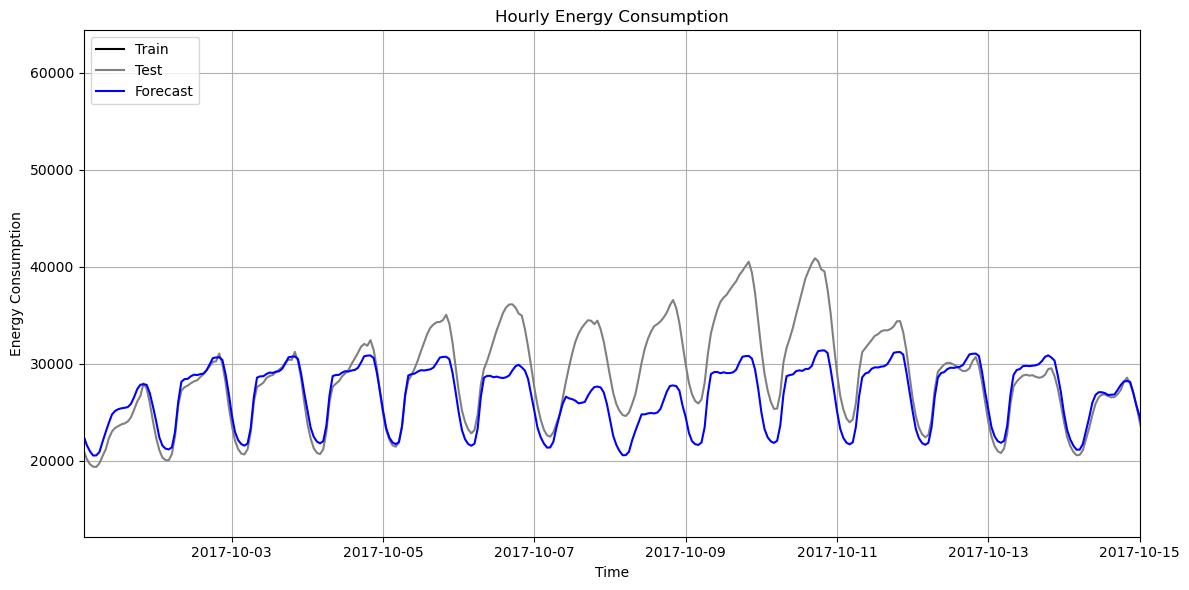

In [25]:
# Plot actual and fitted serie
plt.figure(figsize=(12, 6))                                      

plt.plot(train_df.index, train_df['PJME_MW'], label='Train', color='black')       # Train
plt.plot(test_df.index, test_df['PJME_MW'], label='Test', color='gray')           # Test
plt.plot(results.index, results['Prediction'], label='Forecast', color='blue')     # Forecast

plt.title('Hourly Energy Consumption')                      
plt.xlabel('Time')                                        
plt.ylabel('Energy Consumption')  
plt.xlim(pd.to_datetime('2017-10-01 01:00:00'), pd.to_datetime('2017-10-15 00:00:00'))
#plt.ticklabel_format(style='plain', axis='y')  # Disable scientific notation on y-axis
#plt.ylim(-20,500)
plt.grid(True)                                            
plt.legend(loc=2)                                             
plt.tight_layout()                                       
plt.show();

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

mae = mean_absolute_error(results["PJME_MW"], results["Prediction"])
rmse = np.sqrt(mean_squared_error(results["PJME_MW"], results["Prediction"]))

print(f" MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

 MAE: 2568.55
RMSE: 3595.08


End.